<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/CS6-GMTED_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topography Maps usind Data Science with Python


## **Introduction: Topographic Mapping through Data Science with Python**

Topographic maps are essential cartographic representations that depict the elevation and relief of the Earth’s surface through the use of contour lines, color gradients, and shaded relief. These maps are fundamental tools in a wide array of disciplines, including geomorphology, hydrology, civil engineering, environmental planning, and natural hazard assessment. Traditionally produced through field surveys and photogrammetric techniques, the generation and analysis of topographic data has been profoundly transformed by the advent of geospatial data science and the widespread availability of remote sensing datasets.

In the context of data science, topographic mapping involves the acquisition, processing, analysis, and visualization of elevation data using computational tools. Python, due to its simplicity, versatility, and extensive ecosystem of geospatial libraries, has become a language of choice for performing such tasks. The integration of libraries such as `rasterio` for raster data manipulation, `elevation` for retrieving digital elevation models (DEMs), `cartopy` for cartographic projections and overlays, and `matplotlib` or `pygmt` for visualization enables the creation of high-resolution, aesthetically compelling topographic maps with minimal manual intervention.

These libraries facilitate the automated processing of satellite-derived elevation models, such as the Shuttle Radar Topography Mission (SRTM) and Earth Relief datasets, allowing researchers to focus on the analysis and interpretation of the terrain. Applications include the generation of contour maps, slope and aspect models, hillshading for visual enhancement, and the integration of hydrological or geological layers for multi-criteria analysis. Moreover, Python’s integration with scientific computing frameworks makes it possible to couple topographic data with machine learning or statistical models for tasks such as landslide susceptibility mapping, watershed delineation, or terrain classification.

This study aims to explore the use of Python-based data science tools for the generation and analysis of topographic maps, with a particular focus on the territory of France. France’s diverse terrain, which includes coastal plains, river basins, highland plateaus, and alpine regions, presents an ideal case for demonstrating both the technical workflow and the cartographic richness that can be achieved through programmatic methods. By leveraging open-access elevation data and modern computational tools, we aim to produce maps that are not only scientifically accurate but also visually informative, highlighting the capabilities of open-source technologies in contemporary geospatial analysis.


In [1]:
!pip install -q rasterio cartopy elevation matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.9 MB/s eta 0:00:00


## ETOPO1 1 Arc-Minute Global Relief Model

In August 2008, the National Geophysical Data Center (NGDC), an office of the National Oceanic and Atmospheric Administration (NOAA), developed the ETOPO1 Global Relief Model as an improvement to the ETOPO2v2 Global Relief Model. ETOPO1 is available in "Ice Surface" (top of Antarctic and Greenland ice sheets) and "Bedrock" (base of the ice sheets) versions. Both versions of ETOPO1 were generated from diverse global and regional digital data sets, which were shifted to common horizontal and vertical datums, and then evaluated and edited as needed. Bathymetric, topographic, and shoreline data used in ETOPO1 were obtained from NGDC, Antarctic Digital Database (ADD), European Ice Sheet Modeling Initiative (EISMINT), Scientific Committee on Antarctic Research (SCAR), Japan Oceanographic Data Center (JODC), Caspian Environment Programme (CEP), Mediterranean Science Commission (CIESM), National Aeronautics and Space Administration (NASA), National Snow and Ice Data Center (NSIDC), Scripps Institute of Oceanography (SIO), and Leibniz Institute for Baltic Sea Research (LIBSR). ETOPO1 is vertically referenced to sea level, and horizontally referenced to the World Geodetic System of 1984 (WGS 84). Cell size for ETOPO1 is 1 arc-minute.


---
**Setting our Home**

---

_``We save the root directory of our workspace``_ `'/content'` as `'HOME'` since we will be navigating through the directory to have multiple projects under the same HOME. Additionally, we will have the datasets in the 'datasets' directory, so all datasets are easily accessible for any project.

In [ ]:
# Setting our $HOME to /content
import os
HOME = os.getcwd() # Obtain actual directory
print(HOME)

/content


---
**Mount Google Drive**

---

Next, it _``imports the drive module from the `` `google.colab` ``library``_, which provides functionalities for mounting Google Drive in Google Colab.

Additionally, Google Drive is mounted in Google Colab and made available at the path `/content/drive`. `The user will be prompted to authorize access` to Google Drive. Once authorized, the content of Google Drive will be accessible from that point onwards in the Colab notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
**Create a directory where we can save our dataset**

---

Create the dataset directory (only if it doesn't exist), where we are going to save the dataset with which we are going to work.

In [ ]:
# Create the dataset directory
import os
datasets_dir = os.path.join(HOME, "datasets")
os.makedirs(datasets_dir, exist_ok=True)
print(os.getcwd())

/content



---
**Change to new directory datasets**

---

Check if the file specified by `file` does not exist in the current directory. If it doesn't exist, the code block inside the conditional, which in this case would be downloading the file from the specified URL, is executed. then, it extracts the contents of `era5_wind_wave.nc` into the current directory quietly, overwriting any existing files if necessary.

In [ ]:
# Change to new dataset folder
os.chdir(datasets_dir)
print('dataset_dir =', os.getcwd())

dataset_dir = /content/datasets


---
**Load the dataset**

---

In [ ]:
import requests

# URL real extraída del enlace ofuscado entre _ y _
# https://urldefense.com/v3/__https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/topo/public/GMTED_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_15arc_15arc_15arc_15arc_15arc_15arc_15arc_30arc_30arc_30arc_30arc_30arc_30arc_30arc_GJSlAGGFa3xA6diXXPiM.zip__;!!D9dNQwwGXtA!S2pSgDa9a28Hu-Yfqc7HeoBZgksofhNzO2IgY5xJhIL8Qbf8Ytn95JJvDf0Ri-R-bZfZ_U-kDUiC-ytiJ8_LqA$
url = "https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/topo/public/GMTED_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_15arc_15arc_15arc_15arc_15arc_15arc_15arc_30arc_30arc_30arc_30arc_30arc_30arc_30arc_GJSlAGGFa3xA6diXXPiM.zip"

# Nombre del archivo de salida
output_file = "GMTED.zip"

# Descargar el archivo
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(output_file, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Archivo descargado como {output_file}")
else:
    print(f"Error al descargar: {response.status_code}")


Archivo descargado como GMTED.zip


---
**Unzip the dataset .nc**

---

The '$' symbol allows access to Python variables within shell commands (such as !unzip).


In [ ]:
extracted_dir = "GMTED"
os.makedirs(extracted_dir, exist_ok=True)
!unzip GMTED.zip -d GMTED

Archive:  GMTED.zip
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff  
 extractin

In [ ]:
!apt-get install tree
print(os.getcwd())
!tree $extracted_dir -L 3

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (113 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/datasets
GMTED
├── gmted2010_fgdc_metadata_updated_final_1.xml
├── Spatial Metadata
│   ├── Spatial Metadata.cpg
│   ├── Spatial Metadata.dbf
│   ├── Spatial Metadata.prj
│   ├── Spatial Metadata.shp
│   └── Spatial Metadata.shx
├── usgs_gmted2010_15arcsec_breakline_emphasis_GJS

### What is **GMTED2010**?

**GMTED2010** stands for:

> **Global Multi-resolution Terrain Elevation Data 2010**

It's a **global digital elevation model (DEM)** developed by the **U.S. Geological Survey (USGS)** and the **National Geospatial-Intelligence Agency (NGA)**.

GMTED2010 provides elevation data for the entire Earth and is commonly used in:

* Geographic Information Systems (**GIS**)
* **Hydrological modeling**
* **Climate modeling**
* **Cartography**
* **Remote sensing** and spatial analysis

It replaces and improves upon the older **GTOPO30** dataset.

The extracted folder `GMTED/` contains multiple **GeoTIFF (`.tiff`) raster files**. These are elevation layers at different **resolutions** and with different **statistical representations** of elevation.

#### Example filename breakdown:

```
usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff
```

* `15arcsec`: resolution of 15 arc-seconds (\~500 meters)
* `mean_stat`: represents the **mean elevation** within that grid cell

You also have files with:

* `minimum_stat` → minimum elevation
* `maximum_stat` → maximum elevation
* `median_stat` → median elevation
* `standarddev_stat` → standard deviation
* `systematic_subsample` → systematic sampling
* `breakline_emphasis` → highlights terrain breaklines (like cliffs or ridges)

Other available resolutions:

* `7pnt5arcsec` → 7.5 arc-seconds (\~250 meters)
* `30arcsec` → 30 arc-seconds (\~1 kilometer)


### Other files (metadata):

Inside the folder `GMTED/Spatial Metadata/`, you’ll find several files with extensions like `.shp`, `.dbf`, `.shx`, `.prj`, `.cpg`. These form a **shapefile** — a widely used geospatial vector format.

These files contain **spatial metadata**, such as coverage areas and attributes for GIS software like **QGIS** or **ArcGIS**.

Also included:

```
gmted2010_fgdc_metadata_updated_final_1.xml
```

This is a metadata file in **FGDC (Federal Geographic Data Committee)** format that documents the dataset (coordinate system, publication info, data quality, etc.).


### Summary Table

| File Type            | Description                                               |
| -------------------- | --------------------------------------------------------- |
| `.tiff`              | Elevation rasters at different resolutions and statistics |
| `.shp`, `.dbf`, etc. | Shapefile with spatial metadata for GIS use               |
| `.xml`               | Standard FGDC metadata file                               |



---
**Visualize a TIFF**
---

In [ ]:
!pip install -q rasterio geopandas matplotlib folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 87.9 MB/s eta 0:00:00


In [ ]:
import os

# Navigate to the folder where the files were extracted
tiff_dir = "/content/datasets/GMTED"
tiff_files = [f for f in os.listdir(tiff_dir) if f.endswith(".tiff")]

print("Available GeoTIFF files:")
for f in tiff_files:
    print(f)


Available GeoTIFF files:
usgs_gmted2010_15arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_mean_stat_GJSl

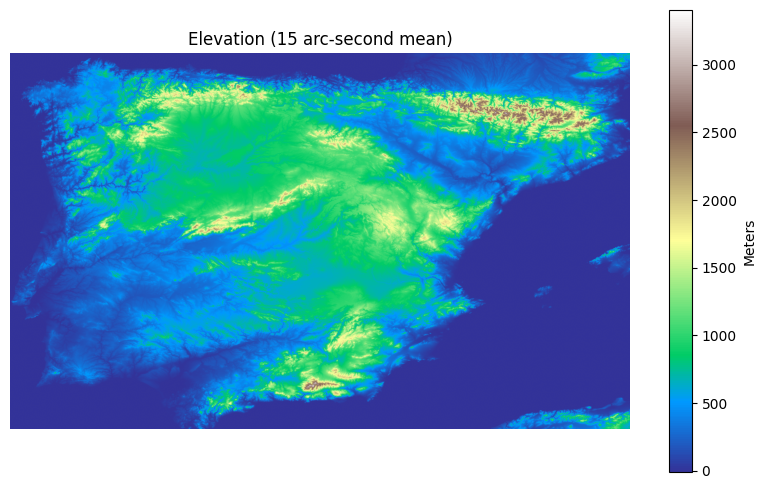

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Choose one TIFF file to display
filename = "usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"
filepath = os.path.join(tiff_dir, filename)

# Open the GeoTIFF
with rasterio.open(filepath) as src:
    elevation = src.read(1)  # Read the first band
    profile = src.profile

# Mask invalid values (optional)
elevation = np.where(elevation == src.nodata, np.nan, elevation)

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(elevation, cmap='terrain')
plt.title("Elevation (15 arc-second mean)")
plt.colorbar(label="Meters")
plt.axis("off")
plt.show()


hnh

In [ ]:
!pip install rasterio geopandas matplotlib shapely


---
**Descargar el shapefile de países (Natural Earth)**

---

[Natural Earth](https://www.naturalearthdata.com/) is a public domain map dataset available at 1:10m, 1:50m, and 1:110 million scales. Featuring tightly integrated vector and raster data, with Natural Earth you can make a variety of visually pleasing, well-crafted maps with cartography or GIS software.

Natural Earth was built through a collaboration of many [volunteers](https://www.naturalearthdata.com/about/contributors/) and is supported by [NACIS (North American Cartographic Information Society)](http://www.nacis.org/), and is free for use in any type of project (see our Terms of Use page for more information).


In [ ]:
print(os.getcwd())

!mkdir -p countries_shapefile

!wget -q -O countries_shapefile/ne_10m_admin_0_countries.shp https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.shp
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.shx https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.shx
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.dbf https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.dbf
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.prj https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.prj
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.cpg https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.cpg


/content/datasets


In [ ]:
!tree $countries_shapefile -L 2

.
├── countries_shapefile
│   ├── ne_10m_admin_0_countries.cpg
│   ├── ne_10m_admin_0_countries.dbf
│   ├── ne_10m_admin_0_countries.prj
│   ├── ne_10m_admin_0_countries.shp
│   ├── ne_10m_admin_0_countries.shx
│   ├── ne_110m_admin_0_countries.cpg
│   ├── ne_110m_admin_0_countries.dbf
│   ├── ne_110m_admin_0_countries.prj
│   ├── ne_110m_admin_0_countries.shp
│   └── ne_110m_admin_0_countries.shx
├── countries.zip
├── GMTED
│   ├── gmted2010_fgdc_metadata_updated_final_1.xml
│   ├── Spatial Metadata
│   ├── usgs_gmted2010_15arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa

---
**Read shapefile  from Spain**

---

[Natural earth vector](https://github.com/nvkelso/natural-earth-vector) solves a problem: finding suitable data for making small-scale maps. In a time when the web is awash in geospatial data, cartographers are forced to waste time sifting through confusing tangles of poorly attributed data to make clean, legible maps. Because your time is valuable, Natural Earth data comes ready-to-use.

In [ ]:
import geopandas as gpd

# Cargar shapefile
world = gpd.read_file("countries_shapefile/ne_10m_admin_0_countries.shp")

# Filtrar España
spain = world[world["NAME"] == "Spain"]

# Asegurar CRS WGS84
spain = spain.to_crs("EPSG:4326")

print(spain)


         featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
66  Admin-0 country          0          2      Spain    ESP         0      2   

                 TYPE TLC  ADMIN  ... FCLASS_TR  FCLASS_ID FCLASS_PL  \
66  Sovereign country   1  Spain  ...      None       None      None   

   FCLASS_GR  FCLASS_IT FCLASS_NL FCLASS_SE  FCLASS_BD FCLASS_UA  \
66      None       None      None      None       None      None   

                                             geometry  
66  MULTIPOLYGON (((-5.34073 35.84736, -5.3629 35....  

[1 rows x 169 columns]


In [ ]:
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# Abrir el raster (pon la ruta correcta de tu archivo)
raster_path = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"

with rasterio.open(raster_path) as src:
    # Recortar usando la geometría de España
    out_image, out_transform = mask(src, spain.geometry, crop=True)
    out_meta = src.meta.copy()

# Actualizar metadatos para el nuevo raster recortado
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Guardar raster recortado
recortado_path = "raster_recortado_espana.tif"
with rasterio.open(recortado_path, "w", **out_meta) as dest:
    dest.write(out_image)


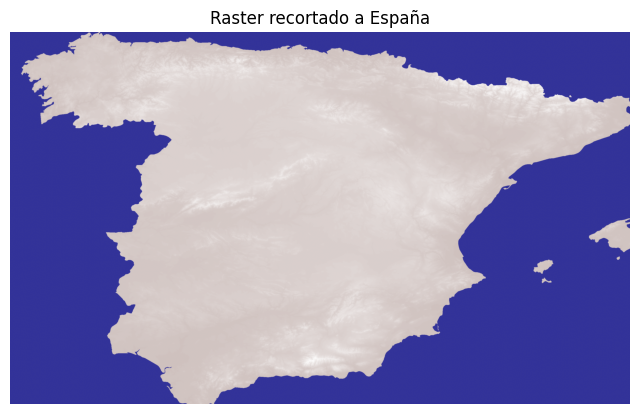

In [ ]:
with rasterio.open(recortado_path) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    raster_plot = src.read(1)
    ax.imshow(raster_plot, cmap='terrain')
    ax.set_title("Raster recortado a España")
    plt.axis('off')
    plt.show()


Now we have elevation values corresponding solely to those in Spain however there is still an issue. By default rasterio.mask.mask will fill all values which are not within the Spain polygon with 0. While this is sensible these 0’s will make the plotting tricky because they act as an anchor at the bottom of the colourmap and if there is a large gap between 0 and the minimum elevation value in the Spain data then you get the map seen above, with real data in one half of the colourmap and the other half of the colourmap absent because there is a gap between 0 and the minimum of the real data. For example, if the gap between the 0’s and the minimum value is equal to the gap between the minimum and maximum altitude then only half of the colourmap will actually be used on real data.

To get around this the mask function allows you explicitly set what value will be applied to values not within the Italy polygon with the nodatakeyword. I have included a function below which solves this problem. In the function below I pass the Spain GeoDataFrame and the rasterio dataset object. You’ll notice that the mask function is called twice, first it is called as above and values not within the Spain polygon are returned as 0’s. On the second occasion, the nodata argument is used and the values not part of the Italy polygon are set to be 1 greater than the maximum value in the Spain topography dataset (as calculated with the first mask). The result is that we now have a dataset with no natural gaps in values and the plot is starting to take shape. Also being returned by this function is the value_range variable. This corresponds to the gap between the smallest and largest value in the array and is needed when constructing colourmaps later.

* * *
**Visualize the clipped elevation data for Spain**

* * *

Let's display the clipped raster to see the elevation data focused on Spain.

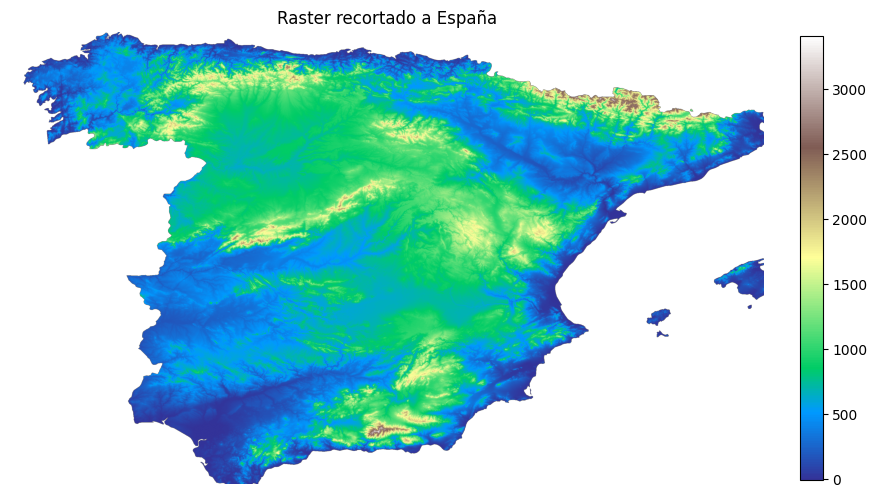

In [ ]:
import numpy as np
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

raster_path = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"

with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, spain.geometry, crop=True, nodata=-9999)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": -9999
})

recortado_path = "raster_recortado_espana.tif"
with rasterio.open(recortado_path, "w", **out_meta) as dest:
    dest.write(out_image)

# Visualización
with rasterio.open(recortado_path) as src:
    data = src.read(1)
    # Reemplazar nodata por nan para la visualización
    data = np.where(data == -9999, np.nan, data)

aspect = out_image.shape[1] / out_image.shape[2]

width = 12  # ancho en pulgadas (puedes cambiar)
height = width * aspect

fig, ax = plt.subplots(figsize=(width, height))
img = ax.imshow(data, cmap='terrain')

# Barra vertical, menos larga (80% de altura)
cbar = plt.colorbar(img, ax=ax, shrink=0.8, pad=0.04)

ax.set_title("Raster recortado a España")
plt.axis('off')
plt.show()

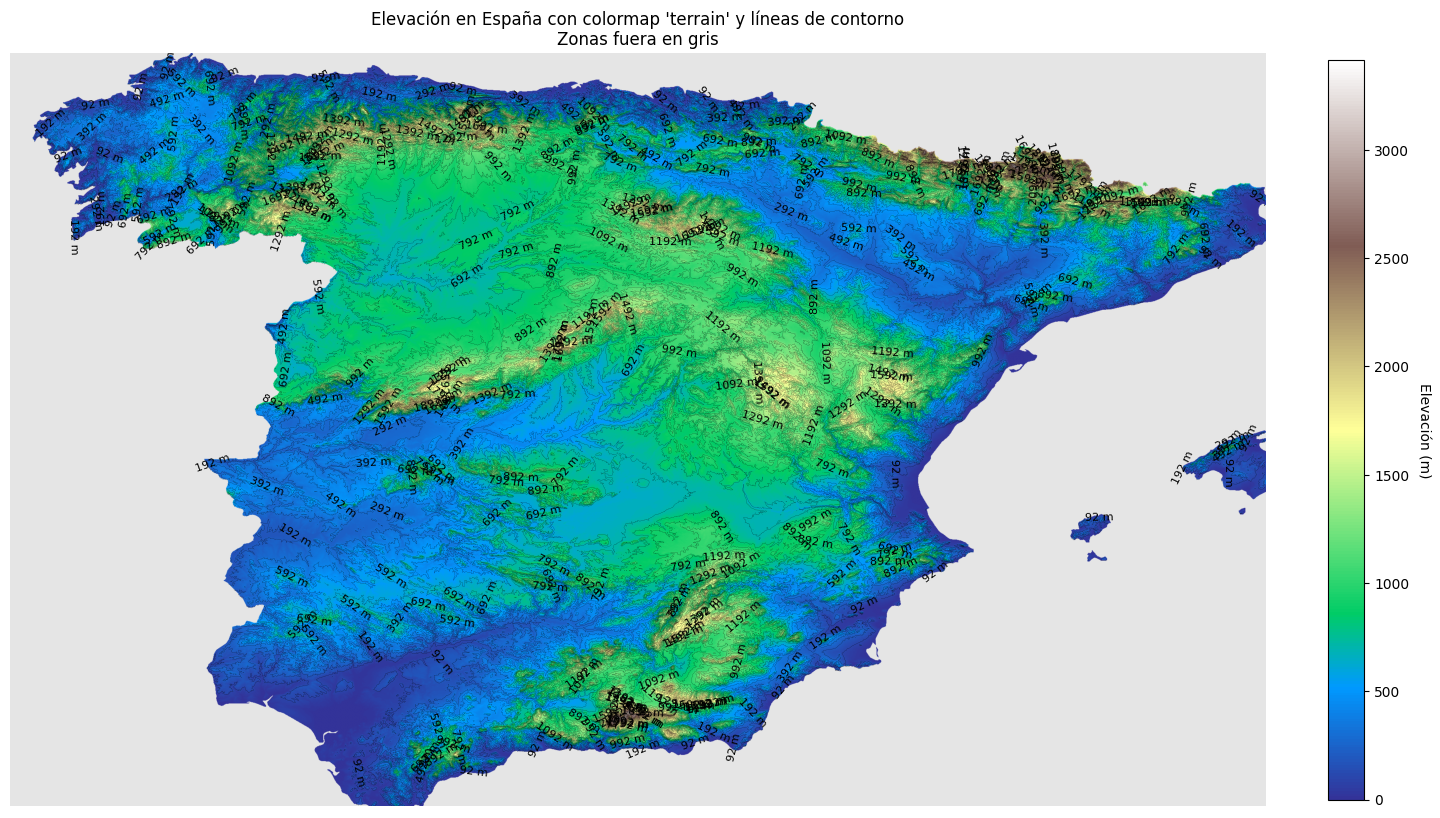

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
import matplotlib

# Leer raster y obtener transform
with rasterio.open(recortado_path) as src:
    data = src.read(1)
    transform = src.transform  # para coordenadas

# Reemplazar nodata (-9999) con np.nan
data = np.where(data == -9999, np.nan, data)

# Definir min y max reales
min_val = int(np.nanmin(data))
max_val = int(np.nanmax(data))
out_val = max_val + 1  # valor fuera de España

# Reemplazar nan con valor fuera de España antes de redondear
data_filled = np.where(np.isnan(data), out_val, data)
data_int = np.rint(data_filled).astype(int)

# Crear colormap con terreno + fondo gris
n_colors = out_val - min_val + 1
terrain = matplotlib.colormaps['terrain']
terrain_colors = [terrain(i / (n_colors - 1)) for i in range(n_colors)]
terrain_colors[-1] = (0.9, 0.9, 0.9, 1.0)  # fondo: gris claro
custom_cmap = ListedColormap(terrain_colors)

# Ajustar aspecto
aspect = data.shape[0] / data.shape[1]
width = 20
height = width * aspect

# Crear coordenadas X e Y para las curvas de nivel
nrows, ncols = data.shape
x = np.arange(ncols)
y = np.arange(nrows)

# Convertir índices de píxeles a coordenadas espaciales usando el transform
xs, _ = rasterio.transform.xy(transform, [0]*ncols, x, offset='center')
_, ys = rasterio.transform.xy(transform, y, [0]*nrows, offset='center')
X, Y = np.meshgrid(xs, ys)

# Visualización
fig, ax = plt.subplots(figsize=(width, height))
img = ax.imshow(data_int - min_val, cmap=custom_cmap, extent=(xs[0], xs[-1], ys[-1], ys[0]))
cbar = plt.colorbar(img, ax=ax, shrink=0.8, pad=0.04)
cbar.set_label("Elevación (m)", rotation=270, labelpad=15)

# Añadir curvas de nivel cada 200 metros
contour_levels = np.arange(min_val, max_val, 100)
contours = ax.contour(X, Y, data, levels=contour_levels, colors='black', linewidths=0.1)
ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')

ax.set_title("Elevación en España con colormap 'terrain' y líneas de contorno\nZonas fuera en gris")
plt.axis('off')
plt.show()


While I think this still looks pretty good, it is still 2D and topography is 3D. So the final thing to do is add hillshade to mimic light shining on the topography. A hillshade is a 3D representation of a surface and are generally rendered in greyscale. The darker and lighter colors represent the shadows and highlights that you would visually expect to see in a terrain model. Hillshades are often used as an underlay in a map, to make the data appear more 3-Dimensional and thus visually interesting. We will use the earthpy hillshade function to generate our hillshade data. There are two parameters that can be tuned and they give significantly different results depending on your dataset. The first is the azimuth value which can range from 0–360 degrees and relates to where the light source is shining from. 0 degrees corresponds to a light source pointing due north. The second is the altitude that the light source is at and these values can range from 1–90. Below are a few examples highlighting how changing the two values can give vastly different results.

* * *
**Visualize the shaded relief representation of the terrain**

* * *

Let's visualize the calculated hillshade to see the shaded relief representation of the terrain.

In [ ]:
!pip install earthpy -q

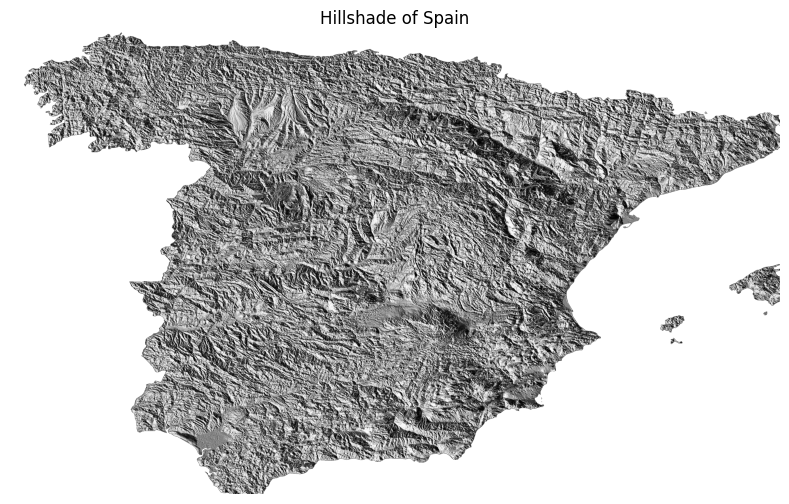

In [ ]:
import earthpy.spatial as es

hillshade = es.hillshade(data, azimuth=240, altitude=1)

# Display the hillshade result
plt.figure(figsize=(10, 6)) # Adjust figure size as needed
plt.imshow(hillshade, cmap='gray', origin='upper') # Use a grayscale colormap
plt.title("Hillshade of Spain")
plt.axis('off') # Turn off axes for a cleaner map
plt.show()

In [ ]:
print(os.getcwd())

/content/datasets


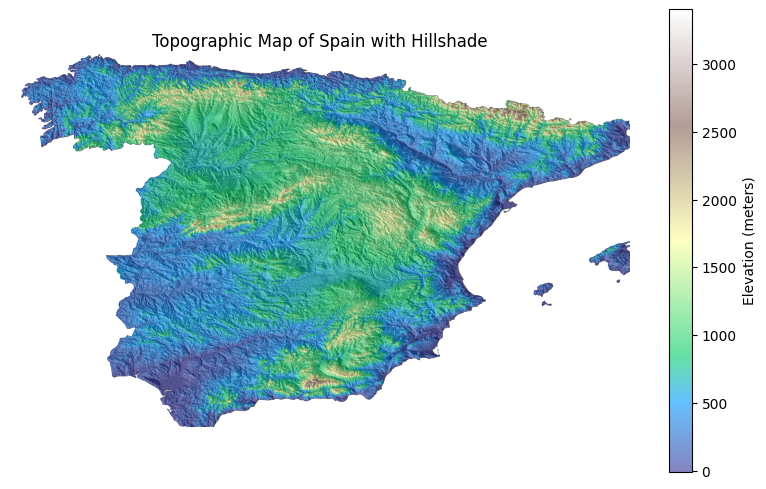

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os
import earthpy.spatial as es # Import earthpy for hillshade

# Paths to the clipped raster and the original GMTED data (to get transform)
clipped_raster_path = "raster_recortado_espana.tif" # Use the clipped Spain raster
gmted_file = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"
gmted_filepath = os.path.join(datasets_dir, gmted_file) # Use the previously defined tiff_dir


# Check if the necessary files exist
if os.path.exists(clipped_raster_path) and os.path.exists(gmted_filepath):
    # Open the clipped raster
    with rasterio.open(clipped_raster_path) as src:
        clipped_data = src.read(1)
        nodata_val = src.nodata
        # Get the transform from the original GMTED file to ensure correct spatial positioning
        with rasterio.open(gmted_filepath) as gmted_src:
             transform = gmted_src.transform


    # Replace nodata values with NaN
    if nodata_val is not None:
        clipped_data = np.where(clipped_data == nodata_val, np.nan, clipped_data)

    # Calculate hillshade from the clipped data
    # Use the clipped_data for hillshade calculation
    # You might need to adjust azimuth and altitude for best results
    hillshade = es.hillshade(clipped_data, azimuth=240, altitude=1)


    # Get the aspect ratio of the clipped data for better visualization
    aspect = clipped_data.shape[0] / clipped_data.shape[1]

    # Set figure size based on aspect ratio
    width = 10  # You can adjust the width as needed
    height = width * aspect

    fig, ax = plt.subplots(figsize=(width, height))

    # Display the hillshade as the base layer
    ax.imshow(hillshade, cmap='gray', origin='upper', extent=[transform.c, transform.c + transform.a * clipped_data.shape[1], transform.f + transform.e * clipped_data.shape[0], transform.f])

    # Display the clipped elevation data with transparency
    # Adjust the alpha value to control transparency (0 is fully transparent, 1 is fully opaque)
    img = ax.imshow(clipped_data, cmap='terrain', origin='upper', extent=[transform.c, transform.c + transform.a * clipped_data.shape[1], transform.f + transform.e * clipped_data.shape[0], transform.f], alpha=0.6)


    # Add a colorbar
    cbar = plt.colorbar(img, ax=ax, label="Elevation (meters)")

    ax.set_title("Topographic Map of Spain with Hillshade")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.axis('off')
    plt.show()

else:
    print(f"Necessary files not found. Please ensure '{clipped_raster_path}' and '{gmted_filepath}' exist.")

/tmp/ipython-input-135-3158601128.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust layout to prevent overlap


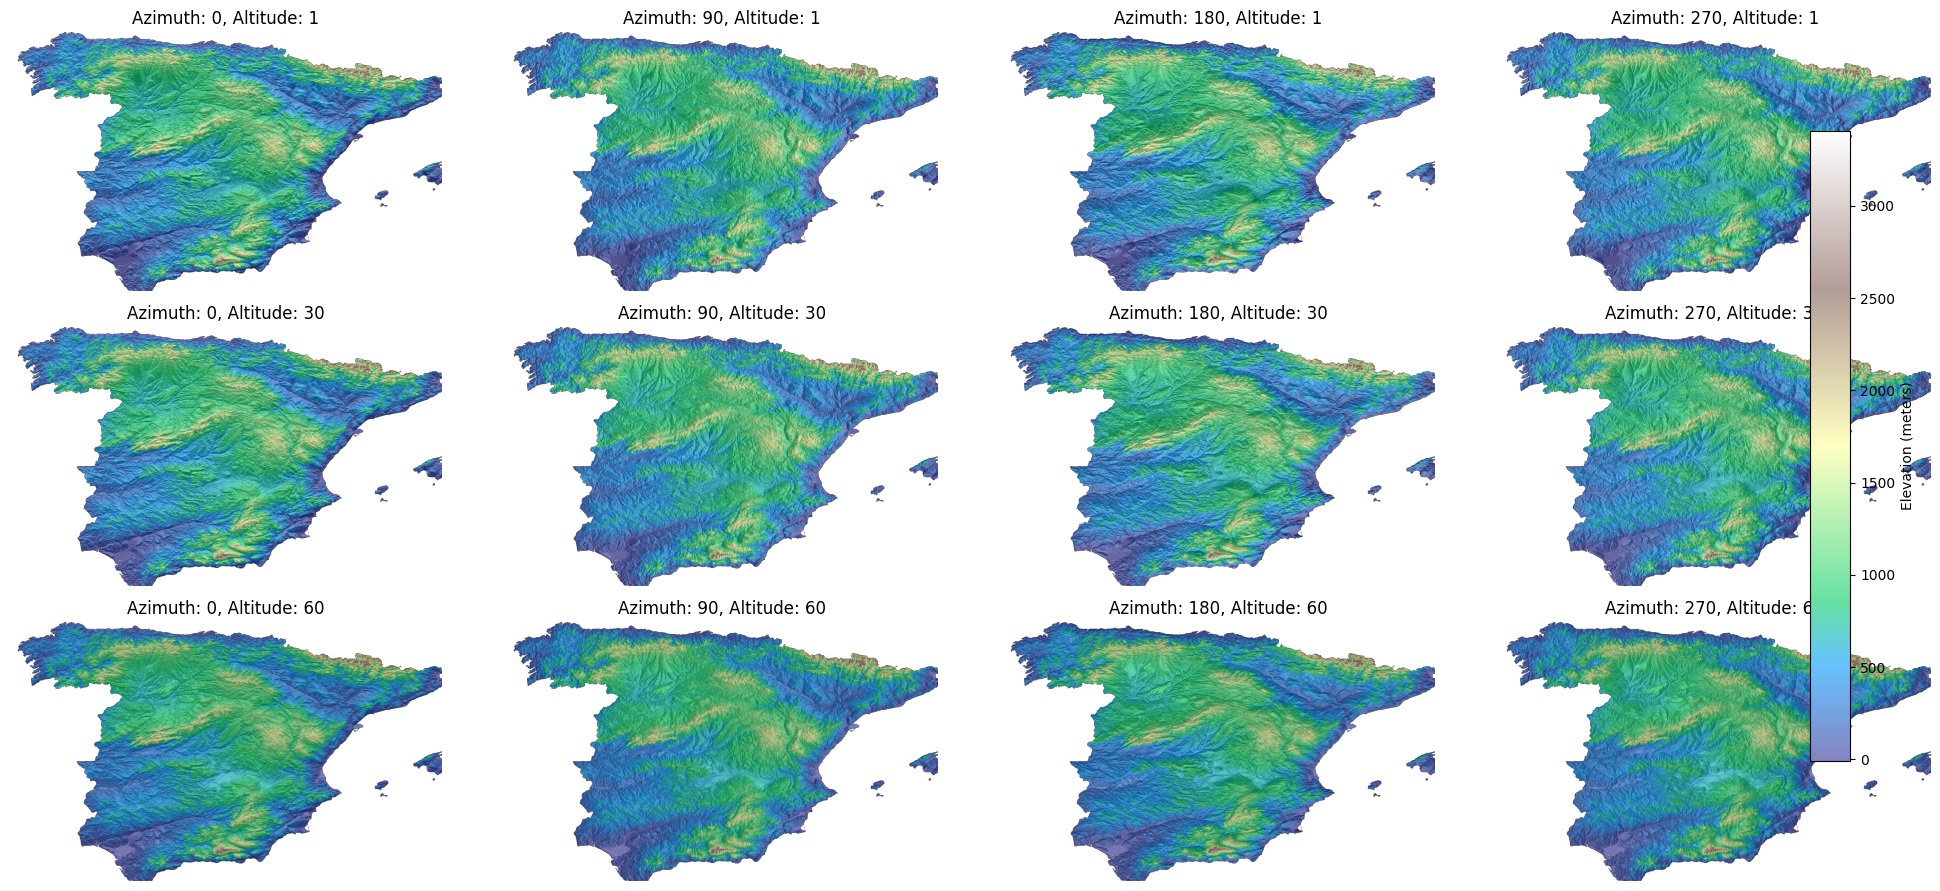

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import os
import earthpy.spatial as es # Import earthpy for hillshade

# Paths to the clipped raster and the original GMTED data (to get transform)
clipped_raster_path = "raster_recortado_espana.tif" # Use the clipped Spain raster
gmted_file = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"
gmted_filepath = os.path.join(datasets_dir, gmted_file) # Use the previously defined tiff_dir


# Check if the necessary files exist and load data
clipped_data = None
transform = None
if os.path.exists(clipped_raster_path) and os.path.exists(gmted_filepath):
    # Open the clipped raster
    with rasterio.open(clipped_raster_path) as src:
        clipped_data = src.read(1)
        nodata_val = src.nodata
        # Get the transform from the original GMTED file to ensure correct spatial positioning
        with rasterio.open(gmted_filepath) as gmted_src:
             transform = gmted_src.transform


    # Replace nodata values with NaN
    if clipped_data is not None and nodata_val is not None:
        clipped_data = np.where(clipped_data == nodata_val, np.nan, clipped_data)

    # Get the aspect ratio of the clipped data for better visualization
    if clipped_data is not None:
        aspect = clipped_data.shape[0] / clipped_data.shape[1]
    else:
        aspect = 1 # Default aspect if data not loaded

else:
    print(f"Necessary files not found. Please ensure '{clipped_raster_path}' and '{gmted_filepath}' exist.")

# Function to plot the topographic map with hillshade for given azimuth and altitude
def plot_topo_with_hillshade(ax, data, transform, azimuth, altitude, cmap='terrain', alpha=0.6):
    """Plots the topographic map with hillshade on a given axes."""
    if data is not None and transform is not None:
        # Calculate hillshade
        hillshade = es.hillshade(data, azimuth=azimuth, altitude=altitude)

        # Display the hillshade as the base layer
        ax.imshow(hillshade, cmap='gray', origin='upper', extent=[transform.c, transform.c + transform.a * data.shape[1], transform.f + transform.e * data.shape[0], transform.f])

        # Display the elevation data with transparency
        img = ax.imshow(data, cmap=cmap, origin='upper', extent=[transform.c, transform.c + transform.a * data.shape[1], transform.f + transform.e * data.shape[0], transform.f], alpha=alpha)

        ax.set_title(f"Azimuth: {azimuth}, Altitude: {altitude}")
        # Turn off the axes
        ax.axis('off')

        ax.set_aspect('equal', adjustable='box') # Ensure correct aspect ratio

        return img # Return the image object for colorbar


# Define the different azimuth and altitude values to test
azimuth_values = [0, 90, 180, 270]
altitude_values = [1, 30, 60]

# Create a grid of subplots
if clipped_data is not None and transform is not None:
    fig, axes = plt.subplots(nrows=len(altitude_values), ncols=len(azimuth_values), figsize=(len(azimuth_values) * 5, len(altitude_values) * 5 * aspect), squeeze=False)

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Iterate through combinations of azimuth and altitude and plot
    for i, altitude in enumerate(altitude_values):
        for j, azimuth in enumerate(azimuth_values):
            ax_index = i * len(azimuth_values) + j
            img = plot_topo_with_hillshade(axes[ax_index], clipped_data, transform, azimuth, altitude)

    # Add a single colorbar for all subplots
    # Adjust the position of the colorbar - you might need to fine-tune the values in the future
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(img, cax=cbar_ax, label="Elevation (meters)")


    plt.tight_layout() # Adjust layout to prevent overlap
    plt.show()
else:
     print("Data not loaded, cannot generate plots.")